# FloodNet Complete Kaggle Notebook 
Includes dataset paths, Functional CNN, EfficientNetB0, ROC-AUC, Grad-CAM fixes, class weighting, CSV/PDF exports.

In [2]:
import os, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import *


2026-06-07 16:55:30.489517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780851330.693470      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780851330.755226      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780851331.223459      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780851331.223503      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780851331.223506      58 computation_placer.cc:177] computation placer alr

In [7]:
for p in ['outputs/figures','outputs/tables','outputs/models']:
    os.makedirs(p,exist_ok=True)

DATASET_PATH='/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge'

FLOODED_PATH=os.path.join(DATASET_PATH,'FloodNet Challenge - Track 1','Train','Labeled','Flooded','image')
NON_FLOODED_PATH=os.path.join(DATASET_PATH,'FloodNet Challenge - Track 1','Train','Labeled','Non-Flooded','image')

print('Flooded:',len(os.listdir(FLOODED_PATH)))
print('Non Flooded:',len(os.listdir(NON_FLOODED_PATH)))


Flooded: 51
Non Flooded: 347


In [8]:
IMG_SIZE=224
images=[]
labels=[]

def load_class(folder,label):
    files=[f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for file in tqdm(files):
        img=cv2.imread(os.path.join(folder,file))
        if img is None:
            continue
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        images.append(img.astype(np.float32)/255.0)
        labels.append(label)

load_class(FLOODED_PATH,1)
load_class(NON_FLOODED_PATH,0)

X=np.array(images,dtype=np.float32)
y=np.array(labels)

print(X.shape,y.shape)

if len(X)==0:
    raise ValueError('No images loaded. Check paths.')


100%|██████████| 347/347 [01:29<00:00,  3.89it/s]

(398, 224, 224, 3) (398,)


In [9]:
summary=pd.DataFrame({'Class':y})
summary.to_csv('outputs/tables/class_distribution.csv',index=False)
print (summary)

     Class
0        1
1        1
2        1
3        1
4        1
..     ...
393      0
394      0
395      0
396      0
397      0

[398 rows x 1 columns]


In [9]:
X_train,X_temp,y_train,y_temp=train_test_split(
X,y,test_size=0.30,stratify=y,random_state=42)

X_val,X_test,y_val,y_test=train_test_split(
X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)

weights=compute_class_weight(
class_weight='balanced',
classes=np.unique(y_train),
y=y_train
)
class_weights={0:weights[0],1:weights[1]}


In [10]:
datagen=ImageDataGenerator(
rotation_range=20,
zoom_range=0.2,
horizontal_flip=True,
vertical_flip=True
)


In [11]:
# Functional CNN (Grad-CAM compatible)
inputs=tf.keras.Input(shape=(224,224,3))

x=Conv2D(32,3,activation='relu')(inputs)
x=MaxPooling2D()(x)

x=Conv2D(64,3,activation='relu')(x)
x=MaxPooling2D()(x)

x=Conv2D(128,3,activation='relu',name='last_conv')(x)
x=MaxPooling2D()(x)

x=Flatten()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.5)(x)

outputs=Dense(1,activation='sigmoid')(x)

cnn=Model(inputs,outputs)

cnn.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)


I0000 00:00:1780845246.770668      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
cnn_history=cnn.fit(
datagen.flow(X_train,y_train,batch_size=16),
validation_data=(X_val,y_val),
epochs=20,
class_weight=class_weights,
callbacks=[
EarlyStopping(patience=5,restore_best_weights=True),
ReduceLROnPlateau(patience=3)
]
)


Epoch 1/20


I0000 00:00:1780845249.955171     130 service.cc:152] XLA service 0x7a2bdc004c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780845249.955211     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780845250.355545     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/18 ━━━━━━━━━━━━━━━━━━━━ 1:32 5s/step - accuracy: 0.5000 - loss: 0.8407

I0000 00:00:1780845253.788374     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 419ms/step - accuracy: 0.6295 - loss: 0.7675 - val_accuracy: 0.8667 - val_loss: 0.3551 - learning_rate: 0.0010
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.6691 - loss: 0.6944 - val_accuracy: 0.8833 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.7338 - loss: 0.5873 - val_accuracy: 0.5000 - val_loss: 1.0777 - learning_rate: 0.0010
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.6223 - loss: 0.6539 - val_accuracy: 0.6667 - val_loss: 0.5439 - learning_rate: 0.0010
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.7194 - loss: 0.5534 - val_accuracy: 0.8333 - val_loss: 0.4127 - learning_rate: 1.0000e-04
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8417 - loss: 0.5058 - val_accuracy: 0.8500 - val_loss: 0.3405 - learning_rate: 1.0000e-04
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.8453 - loss: 0.5016 - va

In [13]:
base=EfficientNetB0(
weights='imagenet',
include_top=False,
input_shape=(224,224,3)
)

base.trainable=False

x=GlobalAveragePooling2D()(base.output)
x=Dense(128,activation='relu')(x)
x=Dropout(0.3)(x)
out=Dense(1,activation='sigmoid')(x)

eff=Model(base.input,out)

eff.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

eff.fit(
datagen.flow(X_train,y_train,batch_size=16),
validation_data=(X_val,y_val),
epochs=10,
class_weight=class_weights
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6403 - loss: 0.7770 - val_accuracy: 0.8667 - val_loss: 0.6155
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.3417 - loss: 0.7444 - val_accuracy: 0.8667 - val_loss: 0.5603
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.5683 - loss: 0.7087 - val_accuracy: 0.8667 - val_loss: 0.6517
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.5432 - loss: 0.7049 - val_accuracy: 0.1333 - val_loss: 0.7427
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.5144 - loss: 0.7216 - val_accuracy: 0.1333 - val_loss: 0.7087
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.6223 - loss: 0.6976 - val_accuracy: 0.1333 - val_loss: 0.7218
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.5324 - loss: 0.7049 - val_accuracy: 0.8667 - val_loss: 0.6446
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - a

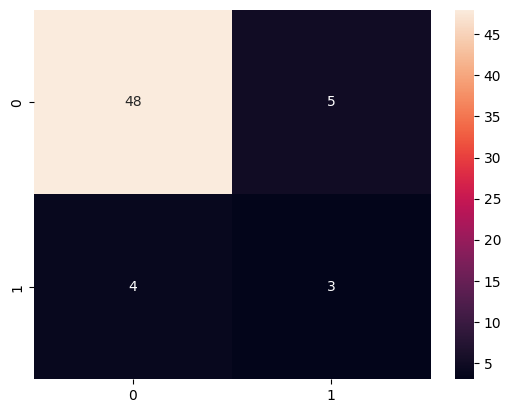

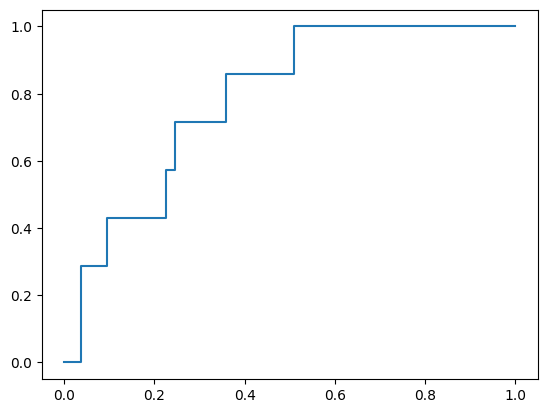

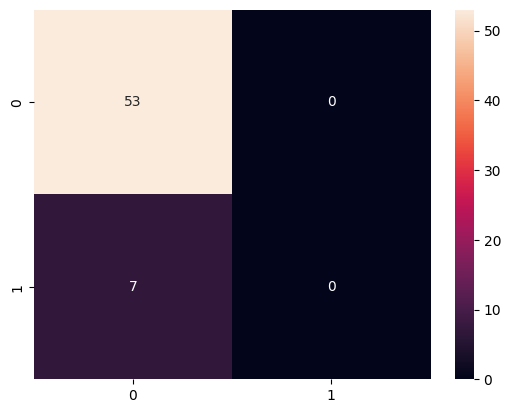

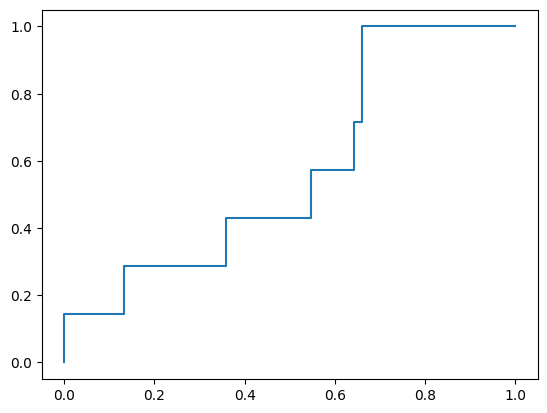

In [14]:
def evaluate_model(model,name):

    probs=model.predict(X_test,verbose=0).flatten()
    preds=(probs>0.5).astype(int)

    report=pd.DataFrame(
        classification_report(
            y_test,
            preds,
            output_dict=True,
            zero_division=0
        )
    ).T

    report.to_csv(f'outputs/tables/{name}_report.csv')

    cm=confusion_matrix(y_test,preds)

    pd.DataFrame(cm).to_csv(
        f'outputs/tables/{name}_cm.csv'
    )

    plt.figure()
    sns.heatmap(cm,annot=True,fmt='d')
    plt.savefig(f'outputs/figures/{name}_cm.pdf')
    plt.show()
    plt.close()

    fpr,tpr,_=roc_curve(
        y_test.ravel(),
        probs.ravel()
    )

    plt.figure()
    plt.plot(fpr,tpr)
    plt.savefig(f'outputs/figures/{name}_roc.pdf')
    plt.show()
    plt.close()

    return [
        accuracy_score(y_test,preds),
        precision_score(y_test,preds,zero_division=0),
        recall_score(y_test,preds,zero_division=0),
        f1_score(y_test,preds,zero_division=0)
    ]

cnn_metrics=evaluate_model(cnn,'cnn')
eff_metrics=evaluate_model(eff,'efficientnet')


<Figure size 600x400 with 0 Axes>

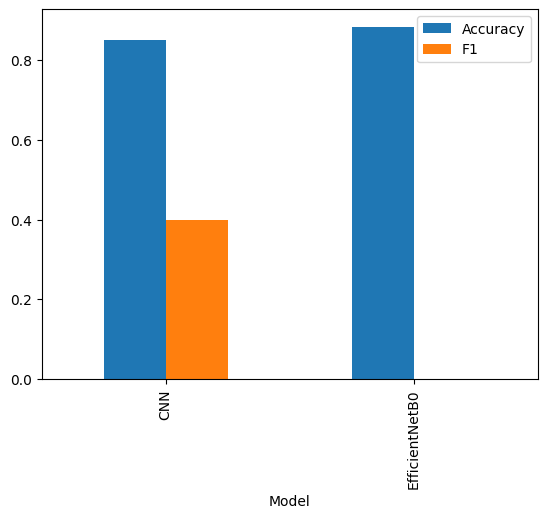

In [15]:
comparison=pd.DataFrame({
'Model':['CNN','EfficientNetB0'],
'Accuracy':[cnn_metrics[0],eff_metrics[0]],
'Precision':[cnn_metrics[1],eff_metrics[1]],
'Recall':[cnn_metrics[2],eff_metrics[2]],
'F1':[cnn_metrics[3],eff_metrics[3]]
})

comparison.to_csv(
'outputs/tables/model_comparison.csv',
index=False
)

plt.figure(figsize=(6,4))
comparison.set_index('Model')[['Accuracy','F1']].plot(kind='bar')
plt.savefig('outputs/figures/model_comparison.pdf')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


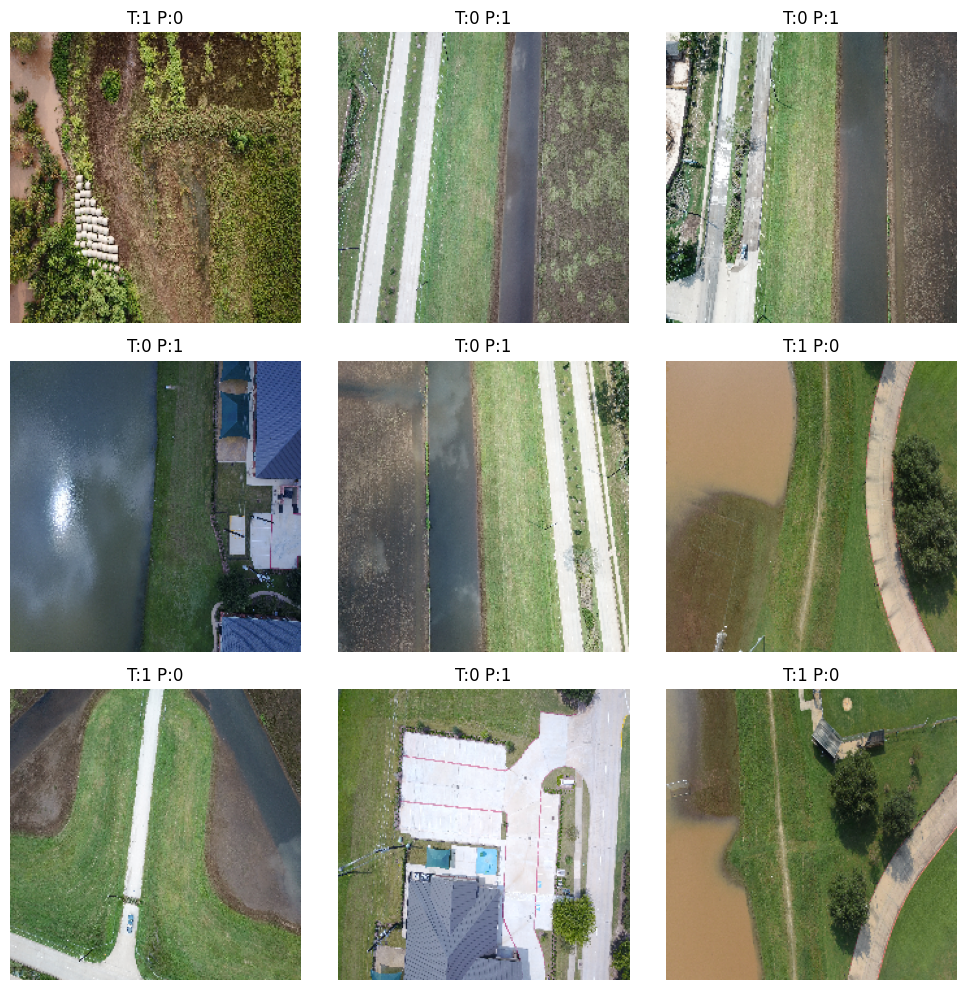

In [17]:
probs=cnn.predict(X_test).flatten()
preds=(probs>0.5).astype(int)
wrong=np.where(preds!=y_test)[0]

fig,ax=plt.subplots(3,3,figsize=(10,10))
for i,idx in enumerate(wrong[:9]):
    ax[i//3,i%3].imshow(X_test[idx])
    ax[i//3,i%3].set_title(f'T:{y_test[idx]} P:{preds[idx]}')
    ax[i//3,i%3].axis('off')
plt.tight_layout()
plt.savefig('outputs/figures/error_analysis.pdf')


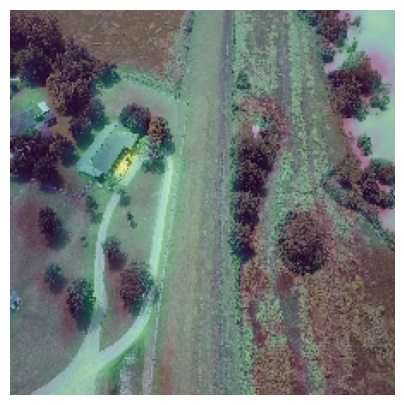

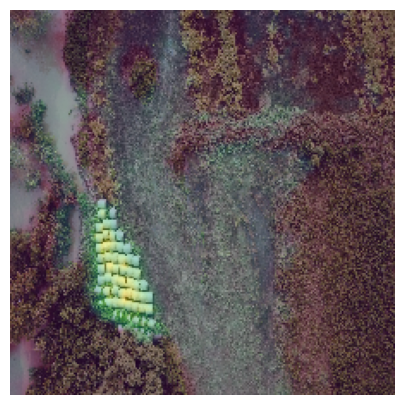

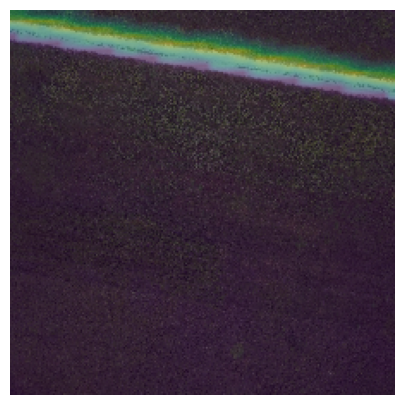

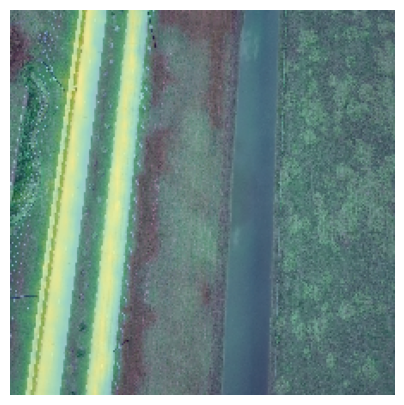

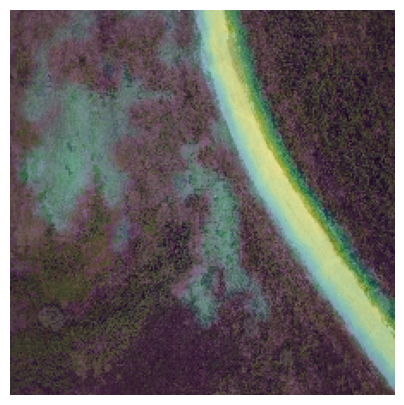

In [18]:
#Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model=tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs,predictions=grad_model(
            img_array,
            training=False
        )
        loss=predictions[:,0]

    grads=tape.gradient(loss,conv_outputs)

    pooled_grads=tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    heatmap=tf.reduce_sum(
        pooled_grads*conv_outputs[0],
        axis=-1
    )

    heatmap=tf.maximum(heatmap,0)
    heatmap/=tf.reduce_max(heatmap)+1e-8

    return heatmap.numpy()

for i in range(min(5,len(X_test))):

    img_tensor=tf.convert_to_tensor(
        np.expand_dims(X_test[i],0),
        dtype=tf.float32
    )

    heatmap=make_gradcam_heatmap(
        img_tensor,
        cnn,
        'last_conv'
    )

    plt.figure(figsize=(5,5))
    plt.imshow(X_test[i])
    plt.imshow(cv2.resize(heatmap,(224,224)),alpha=0.4)
    plt.axis('off')
    plt.savefig(f'outputs/figures/gradcam_{i+1}.pdf')
    plt.show()
    plt.close()
